# D&D-Lite Balance Simulations

This notebook loads combat rules, item stats, and actor templates from `data.json`, then explores balance questions interactively. The JSON holds reusable rules and templates; the questions themselves live here where they are easier to tweak, visualize, and compare.

The notebook focuses on three views:
- mirrored duel duration curves
- survivability curves across armour and shield choices
- a quadrant plot mapping offense against defense for candidate loadouts


In [1]:
from __future__ import annotations

import json
import random
import statistics
from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
pd.options.display.float_format = "{:.2f}".format

DATA_PATH = Path('data.json')
DEFAULT_ITERATIONS = 12000
BASE_SEED = 42

with DATA_PATH.open('r', encoding='utf-8') as handle:
    DATA = json.load(handle)

DATA_PATH


PosixPath('data.json')

In [ ]:
@dataclass(frozen=True)
class AttackMode:
    name: str
    damage_die: str
    attack_stats: tuple[str, ...]
    range_feet: int


@dataclass(frozen=True)
class CombatantTemplate:
    label: str
    level: int
    max_hp: int
    armor_class: int
    abilities: dict[str, int]
    weapon_name: str
    attack_mode: AttackMode


@dataclass
class CombatantState:
    template: CombatantTemplate
    current_hp: int


def build_item_index(data: dict[str, Any]) -> dict[str, dict[str, Any]]:
    return {
        item['name']: item
        for catalog in data['sections']['appendix']['itemCatalogs']
        for item in catalog['items']
        if item.get('data')
    }


def roll_dice(expression: str, rng: random.Random, *, multiplier: int = 1) -> int:
    count_text, sides_text = expression.lower().split('d', 1)
    count = int(count_text)
    sides = int(sides_text)
    return sum(rng.randint(1, sides) for _ in range(count * multiplier))


def choose_attack_mode(actor_spec: dict[str, Any], weapon_data: dict[str, Any]) -> AttackMode:
    modes = weapon_data['data']['modes']
    preferred_mode = actor_spec.get('weaponMode')

    if preferred_mode:
        selected = next((mode for mode in modes if mode['name'] == preferred_mode), None)
        if selected is None:
            raise ValueError(f"Weapon mode {preferred_mode!r} is not available for {actor_spec['weapon']}.")
    else:
        selected = modes[0]

    return AttackMode(
        name=selected['name'],
        damage_die=selected['damageDie'],
        attack_stats=tuple(selected['attackStats']),
        range_feet=int(selected['rangeFeet']),
    )


def merge_modifiers(target: dict[str, int], modifiers: dict[str, int] | None) -> None:
    if not modifiers:
        return
    for key, value in modifiers.items():
        target[key] = target.get(key, 0) + int(value)


def resolve_actor(
    actor_id: str,
    data: dict[str, Any] = DATA,
    item_index: dict[str, dict[str, Any]] | None = None,
    actor_override: dict[str, Any] | None = None,
) -> CombatantTemplate:
    item_index = item_index or build_item_index(data)
    actor_spec = deepcopy(data['data']['actors'][actor_id])

    if actor_override:
        for key, value in actor_override.items():
            if key == 'abilityModifiers':
                actor_spec['abilityModifiers'] = {**actor_spec['abilityModifiers'], **value}
            else:
                actor_spec[key] = value

    abilities = {key: int(value) for key, value in actor_spec['abilityModifiers'].items()}
    equipment = []

    weapon_name = actor_spec['weapon']
    weapon_data = item_index[weapon_name]
    equipment.append(weapon_data)

    outfit_name = actor_spec.get('outfit')
    if outfit_name:
        equipment.append(item_index[outfit_name])

    for trinket_name in actor_spec.get('trinkets', []):
        equipment.append(item_index[trinket_name])

    for item in equipment:
        merge_modifiers(abilities, item['data'].get('modifiers'))

    derived_stats = data['data']['derivedStats']
    key_values = data['key_values']

    hp_rule = derived_stats['hitPoints']
    hp_base = int(key_values[hp_rule['basePerLevelKey']])
    hp_ability = int(abilities.get(hp_rule['ability'], 0))
    level = int(actor_spec['level'])
    max_hp = (hp_base + hp_ability) * level

    ac_rule = derived_stats['armorClass']
    if outfit_name:
        armor_class = int(item_index[outfit_name]['data']['armorClass'])
    else:
        armor_class = int(key_values[ac_rule['baseKey']])

    for trinket_name in actor_spec.get('trinkets', []):
        armor_class += int(item_index[trinket_name]['data'].get('armorClassBonus', 0))

    attack_mode = choose_attack_mode(actor_spec, weapon_data)

    return CombatantTemplate(
        label=actor_spec.get('label', actor_id),
        level=level,
        max_hp=max_hp,
        armor_class=armor_class,
        abilities=abilities,
        weapon_name=weapon_name,
        attack_mode=attack_mode,
    )


def attack_bonus(template: CombatantTemplate) -> tuple[str, int]:
    stat = max(template.attack_mode.attack_stats, key=lambda name: template.abilities.get(name, 0))
    return stat, int(template.abilities.get(stat, 0))


def attack_once(
    attacker: CombatantTemplate,
    defender: CombatantState,
    data: dict[str, Any],
    rng: random.Random,
) -> dict[str, Any]:
    combat_rules = data['data']['combat']
    attack_die = data['data']['dice']['attackDie']
    natural_roll = roll_dice(attack_die, rng)
    stat_name, stat_bonus = attack_bonus(attacker)
    total = natural_roll + stat_bonus
    is_critical = natural_roll >= int(combat_rules['criticalOn'])

    if combat_rules.get('natural1AlwaysMisses') and natural_roll == 1:
        hit = False
    elif combat_rules.get('natural20AlwaysHits') and natural_roll == 20:
        hit = True
    elif combat_rules['hitRule'] == 'attack_total_gte_ac':
        hit = total >= defender.template.armor_class
    else:
        raise ValueError(f"Unsupported hit rule: {combat_rules['hitRule']}")

    damage = 0
    if hit:
        multiplier = int(combat_rules['criticalDamageDiceMultiplier']) if is_critical else 1
        damage = roll_dice(attacker.attack_mode.damage_die, rng, multiplier=multiplier) + stat_bonus
        damage = max(damage, 0)
        defender.current_hp -= damage

    return {
        'hit': hit,
        'critical': is_critical,
        'damage': damage,
        'attack_total': total,
        'attack_stat': stat_name,
        'natural_roll': natural_roll,
    }


def roll_initiative(template: CombatantTemplate, data: dict[str, Any], rng: random.Random) -> tuple[int, float]:
    rule = data['data']['combat']['initiative']
    total = roll_dice(rule['die'], rng) + int(template.abilities.get(rule['stat'], 0))
    return total, rng.random()


def simulate_duel(
    fighter_one: CombatantTemplate,
    fighter_two: CombatantTemplate,
    data: dict[str, Any] = DATA,
    iterations: int = DEFAULT_ITERATIONS,
    seed: int = BASE_SEED,
    max_rounds: int = 500,
) -> dict[str, Any]:
    rng = random.Random(seed)
    rounds_list: list[int] = []
    turns_list: list[int] = []
    winner_counts = {fighter_one.label: 0, fighter_two.label: 0}

    for _ in range(iterations):
        state_one = CombatantState(fighter_one, fighter_one.max_hp)
        state_two = CombatantState(fighter_two, fighter_two.max_hp)
        order = sorted(
            [state_one, state_two],
            key=lambda state: roll_initiative(state.template, data, rng),
            reverse=True,
        )
        rounds = 0
        turns = 0

        while state_one.current_hp > 0 and state_two.current_hp > 0:
            rounds += 1
            if rounds > max_rounds:
                raise RuntimeError('Combat exceeded the round cap; check for an unwinnable matchup.')

            for acting_state in order:
                defending_state = state_two if acting_state is state_one else state_one
                if acting_state.current_hp <= 0 or defending_state.current_hp <= 0:
                    continue
                attack_once(acting_state.template, defending_state, data, rng)
                turns += 1
                if defending_state.current_hp <= 0:
                    winner_counts[acting_state.template.label] += 1
                    rounds_list.append(rounds)
                    turns_list.append(turns)
                    break

    return {
        'rounds': rounds_list,
        'turns': turns_list,
        'average_rounds': statistics.fmean(rounds_list),
        'median_rounds': statistics.median(rounds_list),
        'average_turns': statistics.fmean(turns_list),
        'winner_counts': winner_counts,
        'iterations': iterations,
    }


def simulate_survivability(
    attacker: CombatantTemplate,
    defender: CombatantTemplate,
    data: dict[str, Any] = DATA,
    iterations: int = DEFAULT_ITERATIONS,
    seed: int = BASE_SEED,
) -> dict[str, Any]:
    rng = random.Random(seed)
    landed_hits: list[int] = []
    attempted_attacks: list[int] = []

    for _ in range(iterations):
        defender_state = CombatantState(defender, defender.max_hp)
        hits = 0
        attacks = 0
        while defender_state.current_hp > 0:
            outcome = attack_once(attacker, defender_state, data, rng)
            attacks += 1
            if outcome['hit']:
                hits += 1
        landed_hits.append(hits)
        attempted_attacks.append(attacks)

    return {
        'landed_hits': landed_hits,
        'attempted_attacks': attempted_attacks,
        'average_landed_hits': statistics.fmean(landed_hits),
        'median_landed_hits': statistics.median(landed_hits),
        'average_attempted_attacks': statistics.fmean(attempted_attacks),
        'median_attempted_attacks': statistics.median(attempted_attacks),
    }


def simulate_attack_profile(
    attacker: CombatantTemplate,
    defender: CombatantTemplate,
    data: dict[str, Any] = DATA,
    attempts: int = 20000,
    seed: int = BASE_SEED,
) -> dict[str, Any]:
    rng = random.Random(seed)
    outcomes = []

    for _ in range(attempts):
        defender_state = CombatantState(defender, defender.max_hp)
        outcomes.append(attack_once(attacker, defender_state, data, rng))

    hits = [outcome for outcome in outcomes if outcome['hit']]
    damages = [outcome['damage'] for outcome in outcomes]

    return {
        'hit_rate': sum(outcome['hit'] for outcome in outcomes) / attempts,
        'critical_rate': sum(outcome['critical'] for outcome in outcomes) / attempts,
        'average_damage_per_attack': statistics.fmean(damages),
        'average_damage_on_hit': statistics.fmean([outcome['damage'] for outcome in hits]) if hits else 0.0,
    }


ITEM_INDEX = build_item_index(DATA)


In [ ]:
def build_actor_frame(data: dict[str, Any] = DATA) -> pd.DataFrame:
    rows = []
    for actor_id, actor in data['data']['actors'].items():
        rows.append({
            'actor_id': actor_id,
            'label': actor['label'],
            'level': actor['level'],
            'weapon': actor['weapon'],
            **actor['abilityModifiers'],
        })
    return pd.DataFrame(rows)


def build_item_frame(data: dict[str, Any] = DATA) -> pd.DataFrame:
    rows = []
    for catalog in data['sections']['appendix']['itemCatalogs']:
        for item in catalog['items']:
            item_data = item.get('data', {})
            rows.append({
                'catalog': catalog['title'],
                'name': item['name'],
                'kind': item_data.get('kind', 'n/a'),
                'armor_class': item_data.get('armorClass'),
                'armor_class_bonus': item_data.get('armorClassBonus'),
                'modes': ', '.join(mode['name'] for mode in item_data.get('modes', [])),
                'modifiers': item_data.get('modifiers', {}),
            })
    return pd.DataFrame(rows)


def loadout_label(weapon: str, outfit: str | None, trinkets: tuple[str, ...]) -> str:
    outfit_label = outfit or 'Unarmoured'
    trinket_label = ' + '.join(trinkets) if trinkets else 'No trinket'
    return f'{weapon} | {outfit_label} | {trinket_label}'


def short_loadout_label(weapon: str, outfit: str | None, trinkets: tuple[str, ...]) -> str:
    weapon_code = {'Sword': 'Swd', 'Warhammer': 'Ham', 'Dagger': 'Dag', 'Crossbow': 'Xbw'}
    outfit_code = {None: 'None', 'Leathers': 'Lth', 'Chainmail': 'Chn', 'Plate': 'Plt'}
    shield_code = 'Sh' if 'Shield' in trinkets else 'NoSh'
    return f"{weapon_code.get(weapon, weapon[:3])}/{outfit_code.get(outfit, 'Cfg')}/{shield_code}"


def duel_duration_curve(
    actor_id: str,
    levels: list[int],
    *,
    weapon: str | None = None,
    outfit: str | None = None,
    trinkets: tuple[str, ...] = (),
    iterations: int = DEFAULT_ITERATIONS,
    seed: int = BASE_SEED,
) -> tuple[pd.DataFrame, dict[int, list[int]]]:
    rows = []
    samples: dict[int, list[int]] = {}

    for index, level in enumerate(levels):
        override = {'level': level, 'trinkets': list(trinkets)}
        if weapon is not None:
            override['weapon'] = weapon
        if outfit is not None:
            override['outfit'] = outfit

        fighter_one = resolve_actor(actor_id, item_index=ITEM_INDEX, actor_override={**override, 'label': 'Fighter A'})
        fighter_two = resolve_actor(actor_id, item_index=ITEM_INDEX, actor_override={**override, 'label': 'Fighter B'})
        result = simulate_duel(fighter_one, fighter_two, iterations=iterations, seed=seed + index)

        rows.append({
            'level': level,
            'max_hp': fighter_one.max_hp,
            'armor_class': fighter_one.armor_class,
            'average_rounds': result['average_rounds'],
            'median_rounds': result['median_rounds'],
            'average_turns': result['average_turns'],
        })
        samples[level] = result['rounds']

    return pd.DataFrame(rows), samples


def survivability_matrix(
    attacker_id: str,
    defender_id: str,
    levels: list[int],
    outfits: list[str | None],
    trinket_sets: list[tuple[str, ...]],
    *,
    attacker_override: dict[str, Any] | None = None,
    iterations: int = DEFAULT_ITERATIONS,
    seed: int = BASE_SEED,
) -> pd.DataFrame:
    attacker = resolve_actor(attacker_id, item_index=ITEM_INDEX, actor_override=attacker_override)
    rows = []
    scenario_index = 0

    for level in levels:
        for outfit in outfits:
            for trinkets in trinket_sets:
                defender = resolve_actor(
                    defender_id,
                    item_index=ITEM_INDEX,
                    actor_override={
                        'level': level,
                        'outfit': outfit,
                        'trinkets': list(trinkets),
                    },
                )
                result = simulate_survivability(
                    attacker,
                    defender,
                    iterations=iterations,
                    seed=seed + scenario_index,
                )
                rows.append({
                    'level': level,
                    'outfit': outfit or 'Unarmoured',
                    'shield': 'Shield' in trinkets,
                    'trinkets': ' + '.join(trinkets) if trinkets else 'None',
                    'loadout': loadout_label(defender.weapon_name, outfit, trinkets),
                    'max_hp': defender.max_hp,
                    'armor_class': defender.armor_class,
                    'average_landed_hits': result['average_landed_hits'],
                    'average_attempted_attacks': result['average_attempted_attacks'],
                    'p90_attempted_attacks': float(np.percentile(result['attempted_attacks'], 90)),
                })
                scenario_index += 1

    return pd.DataFrame(rows)


def loadout_quadrant(
    base_actor_id: str,
    *,
    level: int,
    weapons: tuple[str, ...],
    outfits: tuple[str | None, ...],
    trinket_sets: tuple[tuple[str, ...], ...],
    benchmark_defender_id: str,
    benchmark_attacker_id: str,
    iterations: int = DEFAULT_ITERATIONS,
    seed: int = BASE_SEED,
) -> pd.DataFrame:
    rows = []
    benchmark_defender = resolve_actor(benchmark_defender_id, item_index=ITEM_INDEX, actor_override={'level': level})
    benchmark_attacker = resolve_actor(benchmark_attacker_id, item_index=ITEM_INDEX, actor_override={'level': level})
    combo_index = 0

    for weapon in weapons:
        for outfit in outfits:
            for trinkets in trinket_sets:
                actor = resolve_actor(
                    base_actor_id,
                    item_index=ITEM_INDEX,
                    actor_override={
                        'level': level,
                        'weapon': weapon,
                        'outfit': outfit,
                        'trinkets': list(trinkets),
                    },
                )
                attack_profile = simulate_attack_profile(
                    actor,
                    benchmark_defender,
                    attempts=iterations,
                    seed=seed + combo_index,
                )
                defense_profile = simulate_survivability(
                    benchmark_attacker,
                    actor,
                    iterations=iterations,
                    seed=seed + 1000 + combo_index,
                )

                rows.append({
                    'weapon': weapon,
                    'outfit': outfit or 'Unarmoured',
                    'trinkets': ' + '.join(trinkets) if trinkets else 'None',
                    'loadout': loadout_label(weapon, outfit, trinkets),
                    'short_label': short_loadout_label(weapon, outfit, trinkets),
                    'max_hp': actor.max_hp,
                    'armor_class': actor.armor_class,
                    'offense_score': attack_profile['average_damage_per_attack'],
                    'hit_rate': attack_profile['hit_rate'],
                    'defense_score': defense_profile['average_attempted_attacks'],
                })
                combo_index += 1

    return pd.DataFrame(rows).sort_values(['defense_score', 'offense_score'], ascending=False).reset_index(drop=True)


display(build_actor_frame())
display(build_item_frame().fillna(''))


,actor_id,label,level,weapon,STR,DEX,CON,INT,WIS,CHA
0,balanced_novice,Balanced novice,1,Sword,1,1,1,0,0,-1
1,balanced_swordsman,Balanced swordsman,1,Sword,2,1,1,0,-1,-1
2,armour_test_subject,Armour test subject,1,Sword,1,1,1,0,0,-1


,catalog,name,kind,armor_class,armor_class_bonus,modes,modifiers
0,Weapons,Sword,weapon,,,melee,"{'STR': 1, 'WIS': -1}"
1,Weapons,Dagger,weapon,,,"melee, ranged",{}
2,Weapons,Warhammer,weapon,,,melee,{'DEX': -1}
3,Weapons,Crossbow,weapon,,,ranged,{}
4,Outfits,Robes,outfit,10.00,,,"{'INT': 2, 'WIS': -1}"
5,Outfits,Leathers,outfit,12.00,,,{'WIS': 1}
6,Outfits,Chainmail,outfit,14.00,,,{'CHA': -1}
7,Outfits,Plate,outfit,16.00,,,"{'DEX': -1, 'CON': 1}"
8,Trinkets,Shield,trinket,,2.00,,"{'DEX': -1, 'WIS': 1}"
9,Trinkets,Ruffian's Cloak,trinket,,,,"{'DEX': 1, 'CHA': -1}"


## Question 1: How long does an unarmoured melee duel last?

This keeps the matchup symmetric so you can see how level scaling alone changes time-to-knockout. The line chart answers the expectation question, while the histogram shows whether the average hides a swingy distribution.


,level,max_hp,armor_class,average_rounds,median_rounds,average_turns
0,1,11,10,2.79,3.00,4.97
1,2,22,10,5.40,5.00,10.24
2,3,33,10,8.06,8.00,15.57
3,4,44,10,10.81,11.00,21.07
4,5,55,10,13.53,13.00,26.51


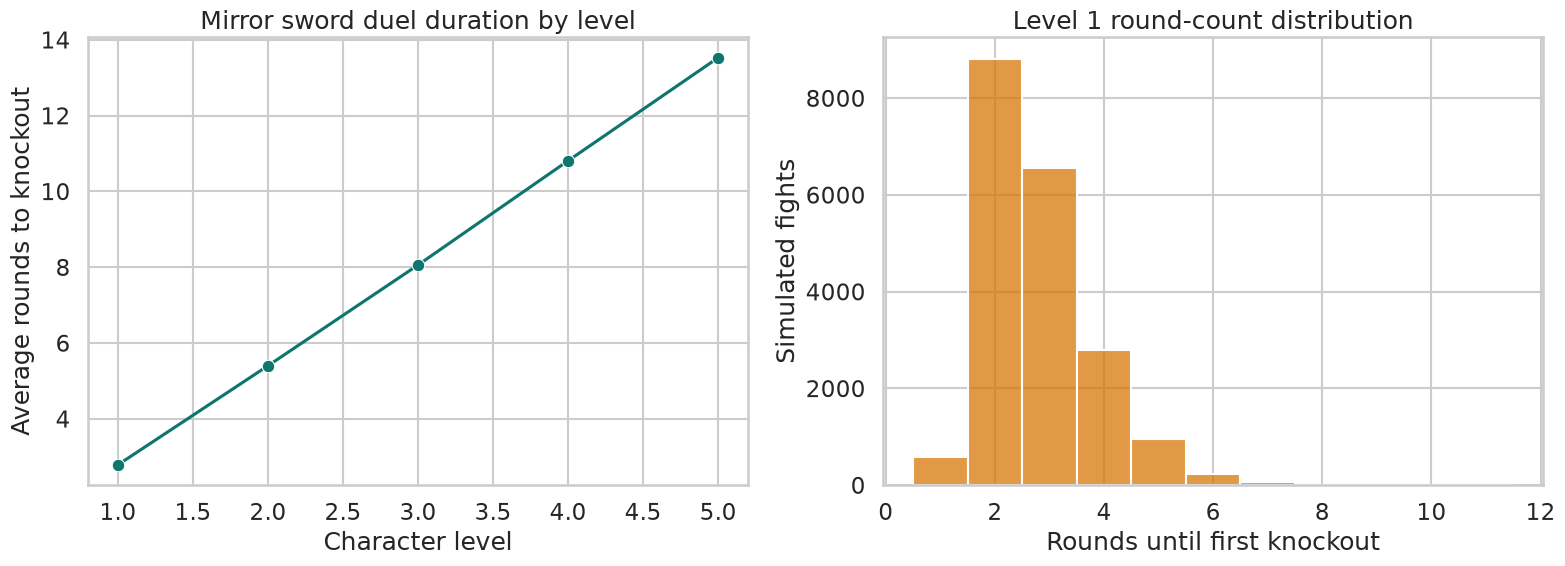

,average_rounds,median_rounds,average_turns
0,2.79,3.00,4.97


In [4]:
duel_df, duel_samples = duel_duration_curve(
    'balanced_novice',
    levels=[1, 2, 3, 4, 5],
    weapon='Sword',
    outfit=None,
    trinkets=(),
    iterations=20000,
    seed=BASE_SEED,
)

display(duel_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.lineplot(data=duel_df, x='level', y='average_rounds', marker='o', color='#0f766e', ax=axes[0])
axes[0].set_title('Mirror sword duel duration by level')
axes[0].set_ylabel('Average rounds to knockout')
axes[0].set_xlabel('Character level')

level_one_rounds = pd.Series(duel_samples[1], name='Rounds')
bins = np.arange(level_one_rounds.min(), level_one_rounds.max() + 2) - 0.5
sns.histplot(level_one_rounds, bins=bins, color='#d97706', ax=axes[1])
axes[1].set_title('Level 1 round-count distribution')
axes[1].set_xlabel('Rounds until first knockout')
axes[1].set_ylabel('Simulated fights')

plt.tight_layout()
plt.show()

duel_df.loc[duel_df['level'] == 1, ['average_rounds', 'median_rounds', 'average_turns']]


## Question 2: How many sword attacks can different adventurers take?

The attacker stays fixed while the defender varies by level, armour, and shield. Plotting both total attacks endured and landed hits endured separates raw durability from evasiveness.


,level,outfit,shield,trinkets,loadout,max_hp,armor_class,average_landed_hits,average_attempted_attacks,p90_attempted_attacks
0,1,Unarmoured,False,None,Sword | Unarmoured | No trinket,11,10,2.12,3.03,5.00
1,1,Unarmoured,True,Shield,Sword | Unarmoured | Shield,11,12,2.11,3.50,6.00
2,1,Leathers,False,None,Sword | Leathers | No trinket,11,12,2.11,3.54,6.00
3,1,Leathers,True,Shield,Sword | Leathers | Shield,11,14,2.10,4.21,7.00
4,1,Chainmail,False,None,Sword | Chainmail | No trinket,11,14,2.09,4.19,7.00
5,1,Chainmail,True,Shield,Sword | Chainmail | Shield,11,16,2.08,5.18,9.00
6,1,Plate,False,None,Sword | Plate | No trinket,12,16,2.19,5.41,10.00
7,1,Plate,True,Shield,Sword | Plate | Shield,12,18,2.16,7.17,13.00
8,2,Unarmoured,False,None,Sword | Unarmoured | No trinket,22,10,3.72,5.31,8.00
9,2,Unarmoured,True,Shield,Sword | Unarmoured | Shield,22,12,3.71,6.14,9.00


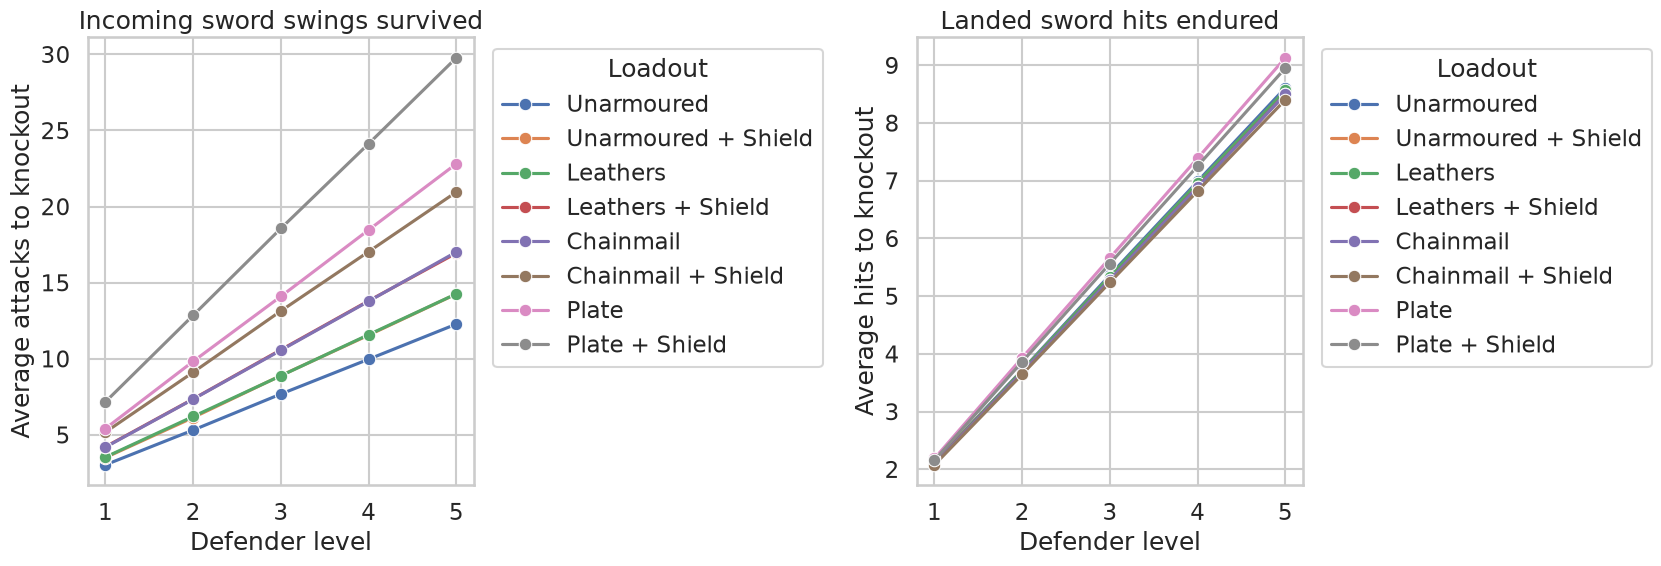

,level,outfit,shield,trinkets,loadout,max_hp,armor_class,average_landed_hits,average_attempted_attacks,p90_attempted_attacks
39,5,Plate,True,Shield,Sword | Plate | Shield,60,18,8.95,29.78,42.00
31,4,Plate,True,Shield,Sword | Plate | Shield,48,18,7.25,24.13,35.00
38,5,Plate,False,None,Sword | Plate | No trinket,60,16,9.13,22.81,31.00
37,5,Chainmail,True,Shield,Sword | Chainmail | Shield,55,16,8.40,20.96,29.00
23,3,Plate,True,Shield,Sword | Plate | Shield,36,18,5.56,18.57,28.00
30,4,Plate,False,None,Sword | Plate | No trinket,48,16,7.39,18.46,26.00
29,4,Chainmail,True,Shield,Sword | Chainmail | Shield,44,16,6.82,17.04,24.00
36,5,Chainmail,False,None,Sword | Chainmail | No trinket,55,14,8.50,17.02,23.00


In [5]:
survival_df = survivability_matrix(
    attacker_id='balanced_swordsman',
    defender_id='armour_test_subject',
    levels=[1, 2, 3, 4, 5],
    outfits=[None, 'Leathers', 'Chainmail', 'Plate'],
    trinket_sets=[(), ('Shield',)],
    iterations=16000,
    seed=BASE_SEED,
)

display(survival_df.sort_values(['level', 'armor_class']))

survival_plot_df = survival_df.copy()
survival_plot_df['series'] = survival_plot_df['outfit'] + np.where(survival_plot_df['shield'], ' + Shield', '')

fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharex=True)
sns.lineplot(data=survival_plot_df, x='level', y='average_attempted_attacks', hue='series', marker='o', ax=axes[0])
axes[0].set_title('Incoming sword swings survived')
axes[0].set_ylabel('Average attacks to knockout')
axes[0].set_xlabel('Defender level')

sns.lineplot(data=survival_plot_df, x='level', y='average_landed_hits', hue='series', marker='o', ax=axes[1])
axes[1].set_title('Landed sword hits endured')
axes[1].set_ylabel('Average hits to knockout')
axes[1].set_xlabel('Defender level')

axes[0].legend(title='Loadout', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].legend(title='Loadout', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

survival_df.sort_values('average_attempted_attacks', ascending=False).head(8)


## Loadout map: offense versus defense

A single scalar rarely tells the full story. This quadrant plot maps each level-3 loadout by offense score on the vertical axis and defense score on the horizontal axis, making tradeoffs easier to spot.

- offense score = average damage per swing into a benchmark level-3 balanced novice
- defense score = average sword swings survived against a benchmark level-3 balanced swordsman


,loadout,max_hp,armor_class,offense_score,hit_rate,defense_score
0,Sword | Plate | Shield,36,18,3.79,0.66,18.64
1,Dagger | Plate | Shield,36,18,2.90,0.61,18.53
2,Warhammer | Plate | Shield,36,18,4.20,0.60,18.47
3,Dagger | Plate | No trinket,36,16,2.89,0.60,14.24
4,Warhammer | Plate | No trinket,36,16,4.16,0.60,14.14
5,Sword | Plate | No trinket,36,16,3.81,0.65,14.07
6,Warhammer | Chainmail | Shield,33,16,4.16,0.60,13.08
7,Sword | Chainmail | Shield,33,16,3.77,0.65,13.05
8,Dagger | Chainmail | Shield,33,16,2.84,0.60,12.99
9,Sword | Leathers | Shield,33,14,3.77,0.65,10.61


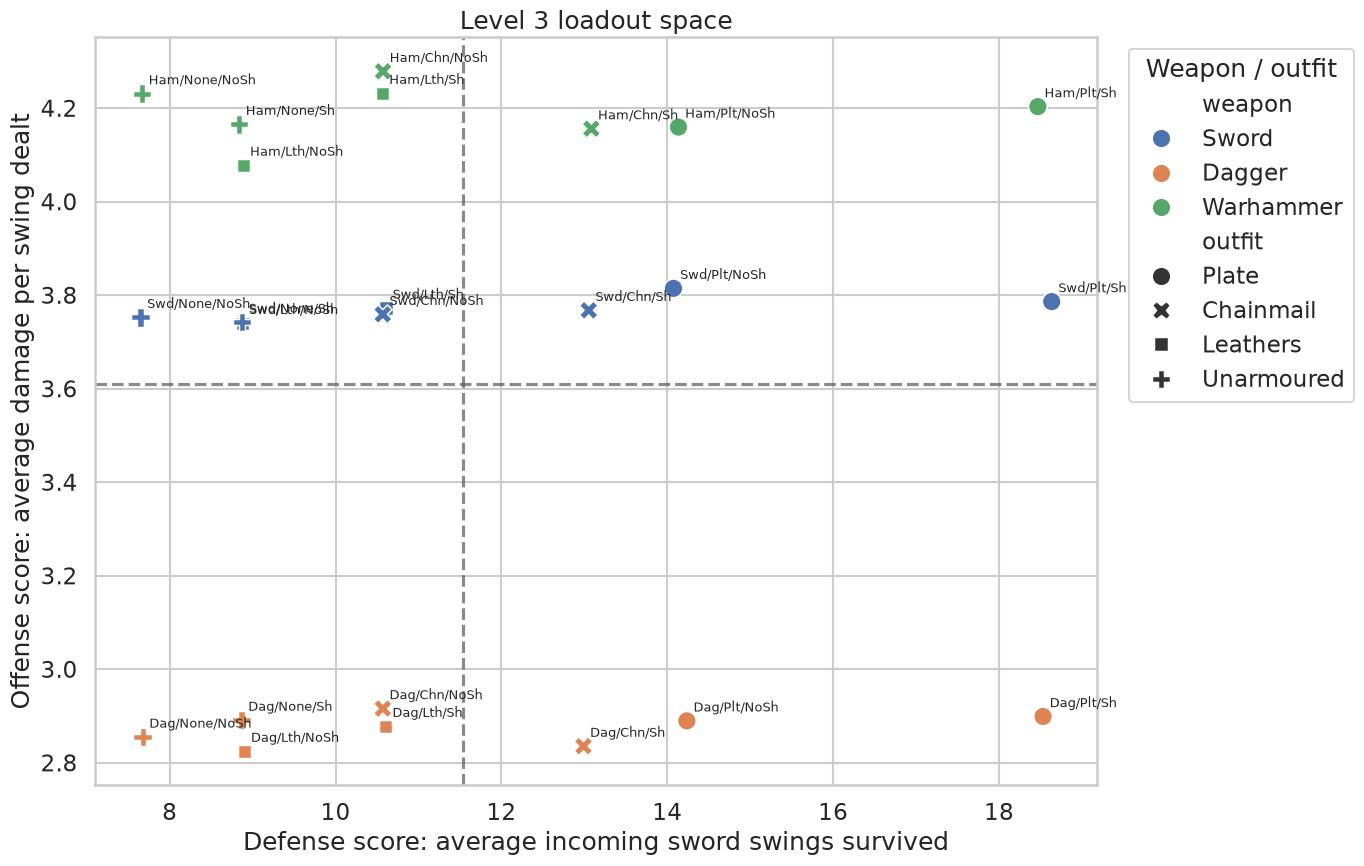

,weapon,outfit,trinkets,loadout,short_label,max_hp,armor_class,offense_score,hit_rate,defense_score
0,Sword,Plate,Shield,Sword | Plate | Shield,Swd/Plt/Sh,36,18,3.79,0.66,18.64
1,Dagger,Plate,Shield,Dagger | Plate | Shield,Dag/Plt/Sh,36,18,2.90,0.61,18.53
2,Warhammer,Plate,Shield,Warhammer | Plate | Shield,Ham/Plt/Sh,36,18,4.20,0.60,18.47
3,Dagger,Plate,None,Dagger | Plate | No trinket,Dag/Plt/NoSh,36,16,2.89,0.60,14.24
4,Warhammer,Plate,None,Warhammer | Plate | No trinket,Ham/Plt/NoSh,36,16,4.16,0.60,14.14
5,Sword,Plate,None,Sword | Plate | No trinket,Swd/Plt/NoSh,36,16,3.81,0.65,14.07
6,Warhammer,Chainmail,Shield,Warhammer | Chainmail | Shield,Ham/Chn/Sh,33,16,4.16,0.60,13.08
7,Sword,Chainmail,Shield,Sword | Chainmail | Shield,Swd/Chn/Sh,33,16,3.77,0.65,13.05
8,Dagger,Chainmail,Shield,Dagger | Chainmail | Shield,Dag/Chn/Sh,33,16,2.84,0.60,12.99
9,Sword,Leathers,Shield,Sword | Leathers | Shield,Swd/Lth/Sh,33,14,3.77,0.65,10.61


In [6]:
quadrant_df = loadout_quadrant(
    base_actor_id='balanced_novice',
    level=3,
    weapons=('Sword', 'Warhammer', 'Dagger'),
    outfits=(None, 'Leathers', 'Chainmail', 'Plate'),
    trinket_sets=((), ('Shield',)),
    benchmark_defender_id='balanced_novice',
    benchmark_attacker_id='balanced_swordsman',
    iterations=12000,
    seed=BASE_SEED,
)

display(quadrant_df[['loadout', 'max_hp', 'armor_class', 'offense_score', 'hit_rate', 'defense_score']].head(12))

fig, ax = plt.subplots(figsize=(14, 9))
sns.scatterplot(
    data=quadrant_df,
    x='defense_score',
    y='offense_score',
    hue='weapon',
    style='outfit',
    s=180,
    ax=ax,
)

for _, row in quadrant_df.iterrows():
    ax.text(row['defense_score'] + 0.08, row['offense_score'] + 0.02, row['short_label'], fontsize=9)

ax.axvline(quadrant_df['defense_score'].mean(), linestyle='--', color='0.35', alpha=0.7)
ax.axhline(quadrant_df['offense_score'].mean(), linestyle='--', color='0.35', alpha=0.7)
ax.set_title('Level 3 loadout space')
ax.set_xlabel('Defense score: average incoming sword swings survived')
ax.set_ylabel('Offense score: average damage per swing dealt')
ax.legend(title='Weapon / outfit', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

quadrant_df.sort_values(['defense_score', 'offense_score'], ascending=False).head(10)


In [7]:
level_one_duel = duel_df.loc[duel_df['level'] == 1].iloc[0]
best_survivors = survival_df.sort_values('average_attempted_attacks', ascending=False).head(5)
best_balanced = quadrant_df.assign(balance_score=quadrant_df['offense_score'] * quadrant_df['defense_score']).sort_values('balance_score', ascending=False).head(5)

summary = pd.DataFrame([
    {
        'finding': 'Level 1 mirrored unarmoured sword duel',
        'value': f"{level_one_duel['average_rounds']:.2f} rounds on average",
    },
    {
        'finding': 'Most durable tested loadout',
        'value': best_survivors.iloc[0]['loadout'],
    },
    {
        'finding': 'Most balanced level 3 loadout by offense x defense',
        'value': best_balanced.iloc[0]['loadout'],
    },
])

display(summary)
display(best_survivors[['level', 'outfit', 'shield', 'max_hp', 'armor_class', 'average_attempted_attacks']])
display(best_balanced[['loadout', 'offense_score', 'defense_score', 'balance_score']])


,finding,value
0,Level 1 mirrored unarmoured sword duel,2.79 rounds on average
1,Most durable tested loadout,Sword | Plate | Shield
2,Most balanced level 3 loadout by offense x def...,Warhammer | Plate | Shield


,level,outfit,shield,max_hp,armor_class,average_attempted_attacks
39,5,Plate,True,60,18,29.78
31,4,Plate,True,48,18,24.13
38,5,Plate,False,60,16,22.81
37,5,Chainmail,True,55,16,20.96
23,3,Plate,True,36,18,18.57


,loadout,offense_score,defense_score,balance_score
2,Warhammer | Plate | Shield,4.20,18.47,77.63
0,Sword | Plate | Shield,3.79,18.64,70.55
4,Warhammer | Plate | No trinket,4.16,14.14,58.79
6,Warhammer | Chainmail | Shield,4.16,13.08,54.38
1,Dagger | Plate | Shield,2.90,18.53,53.72


## Extending the notebook

To ask a new balance question, keep the rules in `data.json` and change the scenario inputs in the notebook cells instead. Useful next variations include:
- swapping the benchmark attacker to a warhammer or dagger build
- comparing ranged loadouts by forcing `weaponMode='ranged'`
- adding new actor templates in `data.json` for glass-cannon, tank, or caster baselines
